<a href="https://colab.research.google.com/github/Madankk-06/Deep-learning-projects/blob/main/8_Semantic_Segmentation_Pipeline_on_Pixel_wise_Grids.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import PyTorch for building the segmentation network.
import torch

# Import neural network modules.
import torch.nn as nn

# Import dataset and image transformation utilities.
import torchvision

# Import Albumentations for image and mask augmentation.
import albumentations as A

# Import plotting library for visualization.
import matplotlib.pyplot as plt

In [2]:
# Implement the basic U-Net feature extraction block.
# Two consecutive convolutions learn rich spatial features.

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),

            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        # Extract local spatial features.
        return self.conv(x)

In [3]:
# Construct the U-Net encoder-decoder architecture.
# Skip connections preserve fine-grained spatial information.

class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Encoder progressively captures semantic features.
        self.encoder1 = DoubleConv(3,64)

        self.pool1 = nn.MaxPool2d(2)

        self.encoder2 = DoubleConv(64,128)

        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck captures high-level representations.
        self.bottleneck = DoubleConv(128,256)

        # Decoder reconstructs pixel-level segmentation masks.
        self.up1 = nn.ConvTranspose2d(256,128,2,2)

        self.decoder1 = DoubleConv(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,2)

        self.decoder2 = DoubleConv(128,64)

        # Generate binary segmentation mask.
        self.output = nn.Conv2d(64,1,1)

    def forward(self,x):

        e1 = self.encoder1(x)

        p1 = self.pool1(e1)

        e2 = self.encoder2(p1)

        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        u1 = self.up1(b)

        # Combine encoder and decoder features
        # using skip connections.
        d1 = self.decoder1(torch.cat([u1,e2],dim=1))

        u2 = self.up2(d1)

        d2 = self.decoder2(torch.cat([u2,e1],dim=1))

        # Predict pixel-wise segmentation probabilities.
        return torch.sigmoid(self.output(d2))

In [4]:
# Implement Soft Dice Loss.
# Dice Loss measures overlap between
# predicted masks and ground truth masks.

def dice_loss(pred,target,smooth=1):

    pred = pred.view(-1)

    target = target.view(-1)

    intersection = (pred*target).sum()

    dice = (2*intersection + smooth) / (

        pred.sum() + target.sum() + smooth

    )

    return 1 - dice

In [5]:
# Combine Binary Cross Entropy and
# Soft Dice Loss for robust segmentation learning.

def combined_loss(pred,target):

    bce = nn.BCELoss()(pred,target)

    dice = dice_loss(pred,target)

    return bce + dice

In [6]:
# Apply image augmentation and preprocessing
# to both images and segmentation masks.

transform = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.RandomRotate90(p=0.5)

])

In [7]:
# Create the U-Net segmentation model.

model = UNet()

In [8]:
# Generate sample medical images
# and corresponding segmentation masks.

images = torch.randn(4,3,128,128)

masks = torch.randint(

    0,

    2,

    (4,1,128,128)

).float()

In [9]:
# Predict pixel-wise segmentation masks.

predictions = model(images)

In [10]:
# Measure segmentation accuracy using
# the composite Dice + BCE loss.

loss = combined_loss(

    predictions,

    masks

)

print("Loss :",loss.item())

Loss : 1.1999715566635132


In [11]:
# Compute pixel-level precision for
# segmentation quality evaluation.

pred_binary = (predictions > 0.5).float()

true_positive = (

    pred_binary * masks

).sum()

precision = true_positive / (

    pred_binary.sum() + 1e-8

)

print("Precision :",precision.item())

Precision : 0.0


In [12]:
# Compute pixel-level recall to measure
# boundary detection performance.

recall = true_positive / (

    masks.sum() + 1e-8

)

print("Recall :",recall.item())

Recall : 0.0


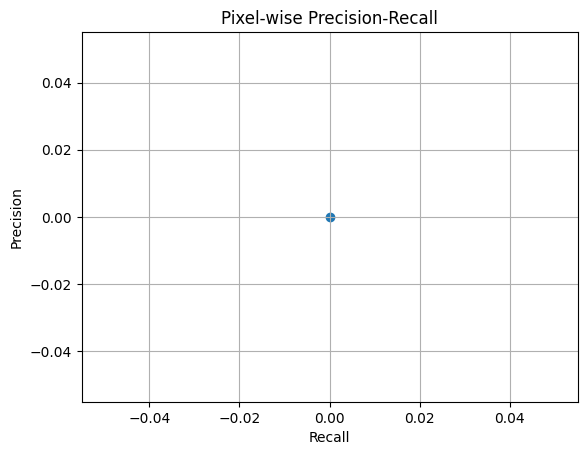

In [13]:
# Plot pixel-wise Precision-Recall values
# for segmentation performance analysis.

plt.scatter(

    recall.item(),

    precision.item()

)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Pixel-wise Precision-Recall")

plt.grid(True)

plt.show()